In [119]:
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


In [120]:
# Instala/actualiza librerías necesarias para este cuaderno
%pip install -q numpy matplotlib scikit-learn pillow 
%pip install -q seaborn
%pip install -q tensorflow keras


import importlib

modules_to_check = [
    ("numpy", "np"),
    ("matplotlib", "plt"),
    ("sklearn", "sklearn"),
    ("tensorflow", "tf"),
    ("seaborn", "sns"),
]

for module_name, alias in modules_to_check:
    try:
        importlib.import_module(module_name)
        print(f"{module_name} OK")
    except ImportError:
        print(f"{module_name} NOT INSTALLED")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
numpy OK
matplotlib OK
sklearn OK
tensorflow OK
seaborn OK


In [121]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Generador con data augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

# Generador para validación y evaluación, sin augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [122]:
data_dir = "./Data"

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = val_generator

Found 47282 images belonging to 5 classes.
Found 11817 images belonging to 5 classes.


In [123]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weight = dict(zip(classes, class_weights_array))

In [124]:
input_size = 64
num_colors = 3

learning_rate = 0.001
# learning_rate = [0.01, 0.001, 0.0001]
epochs = 60
batch_size = 32
# bath_size = [16, 32, 64]
kernel_sizes = 5
#filters = [32, 64, 128]

In [125]:
from tensorflow import keras
def build_model(kernel):
    model = keras.models.Sequential([
        keras.layers.Input(shape=(input_size, input_size, num_colors)),

        keras.layers.Conv2D(32, 5, padding='same',activation='relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.25),

        keras.layers.Conv2D(64, 5, padding='same',activation='relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.25),

        keras.layers.Conv2D(128, 5, padding='same', activation='relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.25),

        keras.layers.Conv2D(256, 5, padding='same', activation='relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.25),

        keras.layers.Flatten(),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.5),

        keras.layers.Dense(5, activation='softmax')
    ])

    model.summary()
    return model

In [126]:
import datetime
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
log_dir = "logs/train/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(log_dir=log_dir)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

### Comprobación de utilizar focal loss para mejorar el rendimiento de la clase 1, que es la que peor rinde

In [127]:
'''
import tensorflow as tf

def focal_loss(gamma=2., alpha=None):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        
        if alpha is not None:
            alpha_weight = y_true * alpha
            loss = alpha_weight * loss
        
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return loss
    '''

'\nimport tensorflow as tf\n\ndef focal_loss(gamma=2., alpha=None):\n    def loss(y_true, y_pred):\n        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)\n        cross_entropy = -y_true * tf.math.log(y_pred)\n        weight = tf.pow(1 - y_pred, gamma)\n        loss = weight * cross_entropy\n\n        if alpha is not None:\n            alpha_weight = y_true * alpha\n            loss = alpha_weight * loss\n\n        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))\n    return loss\n    '

In [ ]:
from tensorflow.keras.optimizers import Adam
print(f"\nProbando kernel={5,5}")

model = build_model(kernel)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    #loss=focal_loss(gamma=2),
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[tensorboard_callback, early_stop, reduce_lr],
    class_weight=class_weight
)
val_acc = max(history.history['val_accuracy'])



Probando kernel=(5, 5)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,128,197 (8.12 MB)

 Trainable params: 2,128,197 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 890s 599ms/step - accuracy: 0.1989 - loss: 1.6098 - val_accuracy: 0.1647 - val_loss: 1.6112 - learning_rate: 0.0010
Epoch 2/60
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 880s 595ms/step - accuracy: 0.2046 - loss: 1.6096 - val_accuracy: 0.3120 - val_loss: 1.6085 - learning_rate: 0.0010
Epoch 3/60
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 1002s 650ms/step - accuracy: 0.2132 - loss: 1.6096 - val_accuracy: 0.3120 - val_loss: 1.6082 - learning_rate: 0.0010
Epoch 4/60
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 897s 606ms/step - accuracy: 0.2198 - loss: 1.6096 - val_accuracy: 0.3120 - val_loss: 1.6088 - learning_rate: 0.0010
Epoch 5/60
 495/1478 ━━━━━━━━━━━━━━━━━━━━ 9:11 561ms/step - accuracy: 0.2048 - loss: 1.6087


Evaluando kernel=(5, 5)
370/370 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step


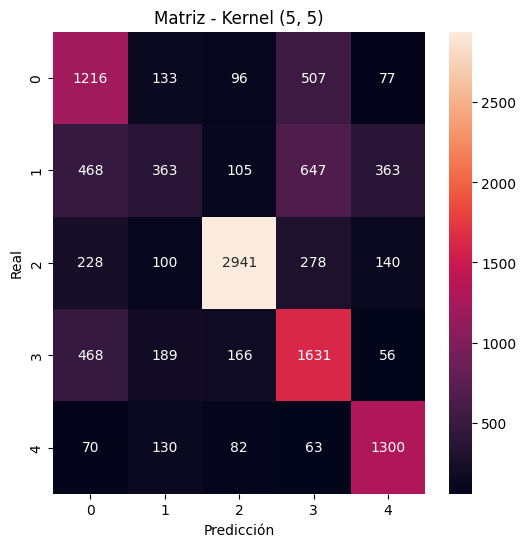

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print(f"\nEvaluando kernel={5,5}")

test_generator.reset()
preds = model.predict(test_generator)

y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Matriz - Kernel {5,5}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Verficación de los distitnos de accuracys y losses para cada una de las combinaciones de hiperparámetros.

In [ ]:
print(f"Kernel {5,5} → Val Accuracy: {val_acc:.4f}")

Kernel (5, 5) → Val Accuracy: 0.6315


Puede que haya una posible desbalance en el dataset, y esto explicaría porque hay uno de las clases que está rindiendo tan poco.

In [ ]:
import numpy as np

unique, counts = np.unique(train_generator.classes, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Clase {u}: {c} muestras")

Clase 0: 8119 muestras
Clase 1: 7786 muestras
Clase 2: 14752 muestras
Clase 3: 10043 muestras
Clase 4: 6582 muestras


In [ ]:
print(class_weight)

{0: np.float64(1.164724719793078), 1: np.float64(1.2145389160030824), 2: np.float64(0.6410249457700651), 3: np.float64(0.9415911580205119), 4: np.float64(1.4367061683378912)}


No hay desbalanceo

In [ ]:
erererer

NameError: name 'erererer' is not defined

In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
import datetime
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
log_dir = "logs/train/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(log_dir=log_dir)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[tensorboard_callback, early_stop, reduce_lr],
    class_weight=class_weight
)

Epoch 1/12
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 1056s 711ms/step - accuracy: 0.2219 - loss: 1.5998 - val_accuracy: 0.2843 - val_loss: 1.5868 - learning_rate: 0.0010
Epoch 2/12
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 323s 218ms/step - accuracy: 0.2593 - loss: 1.5812 - val_accuracy: 0.3294 - val_loss: 1.5260 - learning_rate: 0.0010
Epoch 3/12
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 317s 214ms/step - accuracy: 0.3197 - loss: 1.5356 - val_accuracy: 0.3976 - val_loss: 1.4553 - learning_rate: 0.0010
Epoch 4/12
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 373s 252ms/step - accuracy: 0.3440 - loss: 1.5037 - val_accuracy: 0.4350 - val_loss: 1.3891 - learning_rate: 0.0010
Epoch 5/12
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 5206s 4s/step - accuracy: 0.3767 - loss: 1.4762 - val_accuracy: 0.4759 - val_loss: 1.3691 - learning_rate: 0.0010
Epoch 6/12
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 358s 242ms/step - accuracy: 0.3990 - loss: 1.4498 - val_accuracy: 0.4945 - val_loss: 1.3078 - learning_rate: 0.0010
Epoch 7/12
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 425s 287ms/

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test accuracy:", test_acc)

370/370 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.5670 - loss: 1.1893
Test accuracy: 0.5669797658920288


370/370 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step


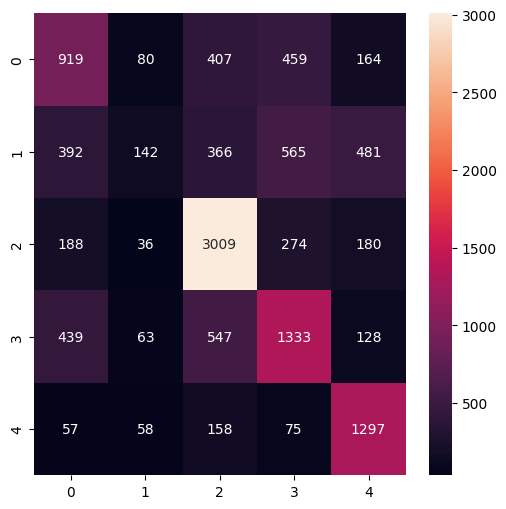

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()